In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


In [2]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")

cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
from sklearn.decomposition import PCA

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)

# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)
combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

adata=ad.AnnData(X=combined_matrix)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)




Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)
Reduced shape: (25932, 50)
Shape after flattening:  (25932, 4096)
Reduced shape: (25932, 50)
(25932, 100)
AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


In [4]:
adata.obs["cell_type"]
# list of all unique cell types
cell_types = adata.obs["cell_type"].unique()
print("Unique cell types:", cell_types)


Unique cell types: ['L5_IT' 'L56_NP' 'L6_CT' 'L23_IT' 'Vip' 'Sst' 'OPC' 'L6b' 'Sncg' 'L6_IT'
 'Lamp5' 'Oligo' 'Endo' 'Microglia' 'Astro' 'VLMC' 'Pvalb' 'L5_ET'
 'L6_IT_Car3' 'L5_PT' 'L45_IT' 'Pericytes' 'SMC']


In [ ]:
covet_ad_st = sc.AnnData(X=st_covet_sqrt_flat)
sc.pp.neighbors(covet_ad_st, use_rep='X')
sc.tl.umap(covet_ad_st)

# Store the UMAP embedding back into st_ad for spatial plotting
st_ad.obsm['X_umap_covet'] = covet_ad_st.obsm['X_umap']

# For single-cell RNA data (sc_ad)
covet_ad_sc = sc.AnnData(X=sc_covet_sqrt_flat)
sc.pp.neighbors(covet_ad_sc, use_rep='X')
sc.tl.umap(covet_ad_sc)

# Store the UMAP embedding back into sc_ad
sc_ad.obsm['X_umap_covet'] = covet_ad_sc.obsm['X_umap']

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


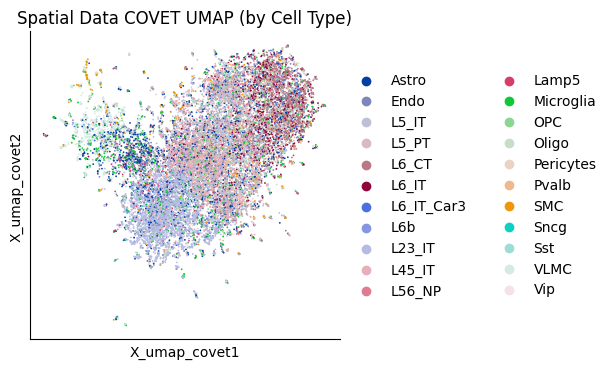

In [11]:
sc.pl.embedding(st_ad, basis='X_umap_covet', color='cell_type', title='Spatial Data COVET UMAP (by Cell Type)')


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


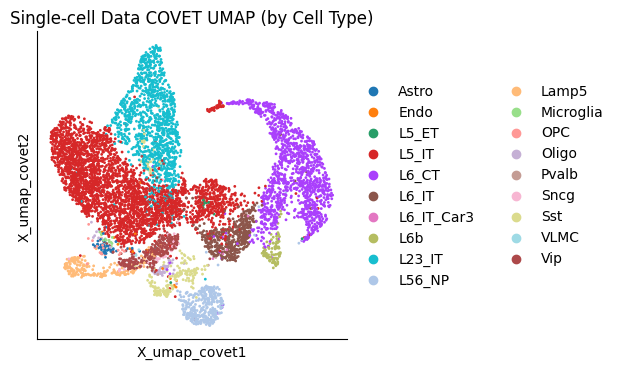

In [12]:
sc.pl.embedding(sc_ad, basis='X_umap_covet', color='cell_type', title='Single-cell Data COVET UMAP (by Cell Type)')


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


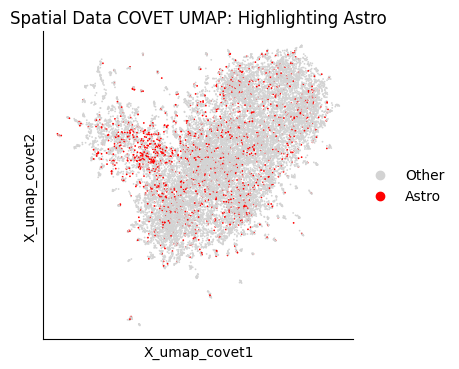

In [18]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Assuming st_ad is your AnnData object with 'X_umap_covet' and 'cell_type'

# 1. Define the cell type you want to highlight
cell_type_to_highlight = "Astro" # <--- IMPORTANT: Replace with the actual cell type name

# 2. Create a new column in .obs for plotting
st_ad.obs['highlight_cell_type'] = st_ad.obs['cell_type'].astype(str) # Ensure it's string type for comparison

# Replace cell types that are NOT the one to highlight with 'Other'
st_ad.obs.loc[st_ad.obs['highlight_cell_type'] != cell_type_to_highlight, 'highlight_cell_type'] = 'Other'

# Convert the new column to a categorical type, ensuring 'Other' is the first category
# This helps with consistent plotting order and color assignment
categories = ['Other', cell_type_to_highlight]
st_ad.obs['highlight_cell_type'] = pd.Categorical(st_ad.obs['highlight_cell_type'], categories=categories)


# 3. Define a custom color map
# You can choose any color for your highlighted cell type.
# 'gray' is a good choice for the 'Other' cells.
custom_colors = {
    'Other': 'lightgray',
    cell_type_to_highlight: 'red' # You can change 'red' to any color you prefer
}

# 4. Plot using sc.pl.embedding with the new column and custom color map
sc.pl.embedding(
    st_ad,
    basis='X_umap_covet',
    color='highlight_cell_type',
    palette=custom_colors,
    title=f'Spatial Data COVET UMAP: Highlighting {cell_type_to_highlight}',
    # Optionally, adjust plotting parameters for better visualization:
    # size=20, # Adjust point size
    # legend_loc='on data' # For placing legend directly on the plot
)

plt.show()

/var/folders/d4/bgr0tr5d43z2xmtq5hk3s4n00000gn/T/ipykernel_8277/2154939531.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['3', '1', '0', '3', '1', ..., '0', '0', '0', '5', '5']
Length: 1526
Categories (6, object): ['0', '1', '2', '3', '4', '5']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  st_ad.obs.loc[st_ad_subset.obs_names, f'{cell_type_of_interest}_covet_clusters'] = \
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:

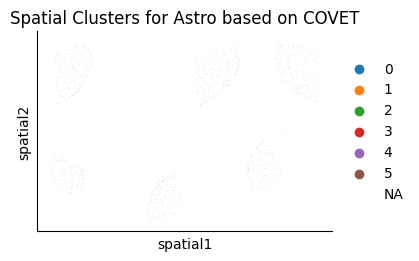

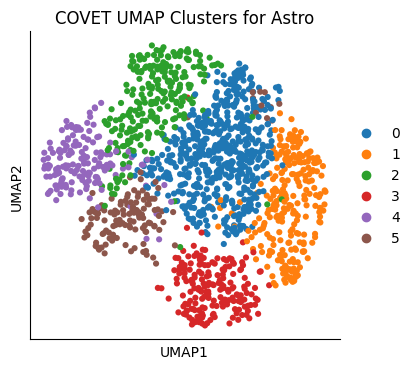

In [29]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

cell_type_of_interest = "Astro"

# Subset the spatial AnnData for the cell type of interest
st_ad_subset = st_ad[st_ad.obs["cell_type"] == cell_type_of_interest].copy()

# Flatten the (64, 64) matrices into 1D vectors for AnnData
covet_sqrt_flat_subset = st_ad_subset.obsm["COVET_SQRT"].reshape(st_ad_subset.shape[0], -1)
covet_ad_subset = sc.AnnData(X=covet_sqrt_flat_subset)

# Compute neighbors and UMAP for the subset
sc.pp.neighbors(covet_ad_subset, use_rep='X')
sc.tl.umap(covet_ad_subset)

# Perform Leiden clustering
sc.tl.leiden(covet_ad_subset, resolution=0.5, key_added=f'{cell_type_of_interest}_covet_clusters')

# --- STEP 3: Transfer cluster assignments back to the original AnnData object ---
# Create a new column in the original st_ad.obs initialized with NaNs
st_ad.obs[f'{cell_type_of_interest}_covet_clusters'] = np.nan

# Assign the cluster labels only to the cells of the specific type
st_ad.obs.loc[st_ad_subset.obs_names, f'{cell_type_of_interest}_covet_clusters'] = \
    covet_ad_subset.obs[f'{cell_type_of_interest}_covet_clusters'].values

# Convert to categorical for proper plotting
st_ad.obs[f'{cell_type_of_interest}_covet_clusters'] = \
    st_ad.obs[f'{cell_type_of_interest}_covet_clusters'].astype('category')

# --- STEP 4: Plot the clusters spatially ---
sq.pl.spatial_scatter(
    st_ad,
    color=f'{cell_type_of_interest}_covet_clusters',
    title=f'Spatial Clusters for {cell_type_of_interest} based on COVET',
    img=False,
)

# Plot the UMAP of the subsetted cells to see the COVET-based sub-clusters
sc.pl.umap(
    covet_ad_subset,
    color=f'{cell_type_of_interest}_covet_clusters',
    title=f'COVET UMAP Clusters for {cell_type_of_interest}'
)

plt.show()

In [16]:
st_ad

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes', 'cell_type_colors'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial', 'X_umap_covet'
    layers: 'X', 'log1p', 'norm'

In [ ]:
import squidpy as sq

sq.pl.spatial_scatter(
	st_ad,
	color='cell_type',
	obsm_key='spatial',
	title='Spatial Plot (by Cell Type)'
)


KeyError: "Spatial key 'spatial' not found in `adata.uns`."

In [9]:
st_ad

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial', 'X_umap_covet'
    layers: 'X', 'log1p', 'norm'

         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


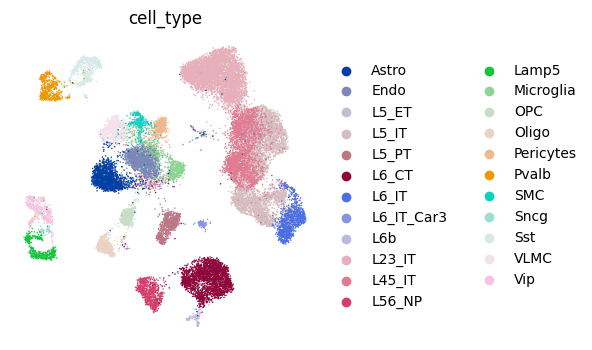

In [5]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], frameon=False)

In [6]:
adata.uns['cell_type_colors']
#list of all colours used in umap for all unique cell types map
print("Unique cell type colors:", adata.uns['cell_type_colors'])
# mapping of cell types to colours
cell_type_colors = dict(zip(cell_types, adata.uns['cell_type_colors']))

Unique cell type colors: ['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b', '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a', '#11c638', '#8dd593', '#c6dec7', '#ead3c6', '#f0b98d', '#ef9708', '#0fcfc0', '#9cded6', '#d5eae7', '#f3e1eb', '#f6c4e1']


In [6]:
cell_type_colors

{'L5_IT': '#023fa5',
 'L56_NP': '#7d87b9',
 'L6_CT': '#bec1d4',
 'L23_IT': '#d6bcc0',
 'Vip': '#bb7784',
 'Sst': '#8e063b',
 'OPC': '#4a6fe3',
 'L6b': '#8595e1',
 'Sncg': '#b5bbe3',
 'L6_IT': '#e6afb9',
 'Lamp5': '#e07b91',
 'Oligo': '#d33f6a',
 'Endo': '#11c638',
 'Microglia': '#8dd593',
 'Astro': '#c6dec7',
 'VLMC': '#ead3c6',
 'Pvalb': '#f0b98d',
 'L5_ET': '#ef9708',
 'L6_IT_Car3': '#0fcfc0',
 'L5_PT': '#9cded6',
 'L45_IT': '#d5eae7',
 'Pericytes': '#f3e1eb',
 'SMC': '#f6c4e1'}

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


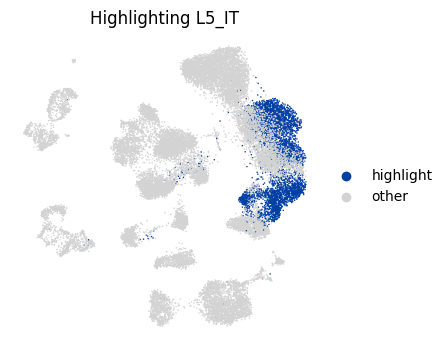

In [7]:
cell_type_to_highlight = "L5_IT"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)



/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


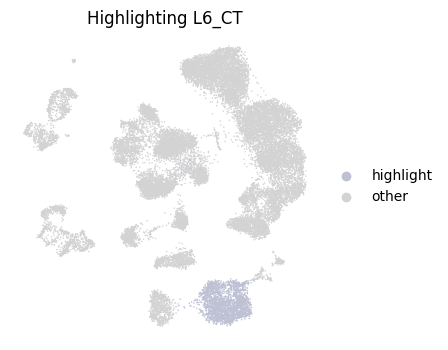

In [8]:
cell_type_to_highlight = "L6_CT"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


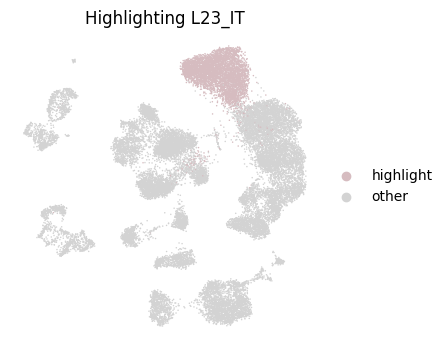

In [9]:
cell_type_to_highlight = "L23_IT"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


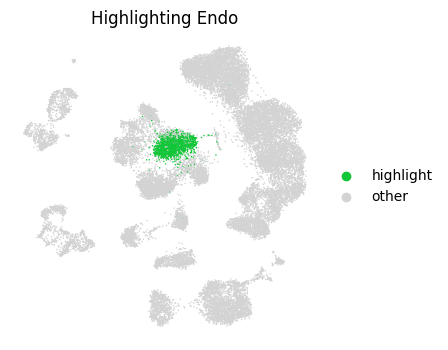

In [10]:
cell_type_to_highlight = "Endo"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


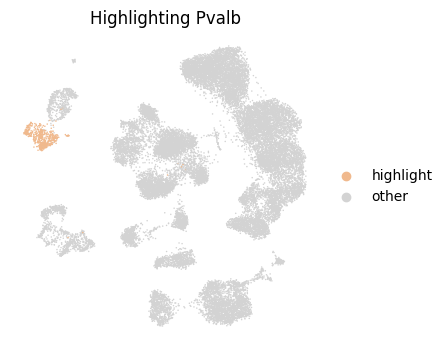

In [11]:
cell_type_to_highlight = "Pvalb"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)



In [12]:
adata_covet=ad.AnnData(X=covet_sqrt_combined)
adata_covet.obs["cell_type"] = combined_cell_types
adata_covet.obsm["covet_sqrt_combined"] = covet_sqrt_combined
print(adata_covet)


AnnData object with n_obs × n_vars = 25932 × 4096
    obs: 'cell_type'
    obsm: 'covet_sqrt_combined'


         Falling back to preprocessing with `sc.pp.pca` and default params.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


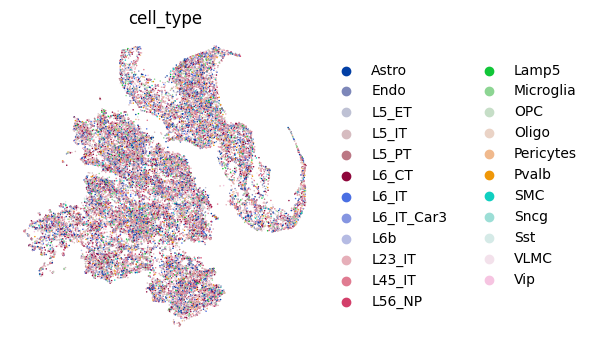

In [13]:
sc.pp.neighbors(adata_covet, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_covet)
sc.pl.umap(adata_covet, color=['cell_type'], frameon=False)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


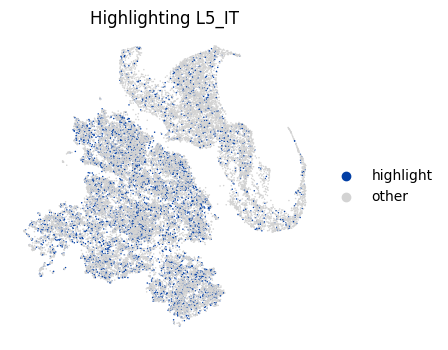

In [14]:
cell_type_to_highlight = "L5_IT"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata_covet.obs["highlight"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata_covet,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"]
)

0            L5_IT
1            L5_IT
2           L56_NP
3            L6_CT
4           L23_IT
           ...    
25927         Endo
25928    Microglia
25929        L5_IT
25930        Astro
25931        Oligo
Name: cell_type, Length: 25932, dtype: category
Categories (23, object): ['Astro', 'Endo', 'L5_ET', 'L5_IT', ..., 'Sncg', 'Sst', 'VLMC', 'Vip']


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


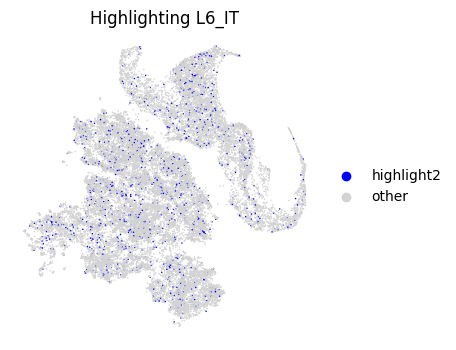

In [15]:
cell_type_to_highlight = "L6_IT"
highlight_color = cell_type_colors[cell_type_to_highlight]
# Make sure 'cell_type' is categorical      
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")
# Create a categorical 'highlight' column with string labels
print(adata_covet.obs["cell_type"])
adata_covet.obs["highlight2"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight2" if x == cell_type_to_highlight else "other"
).astype("category")
# Plot UMAP with highlight vs other
sc.pl.umap(
    adata_covet,
    color="highlight2",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=["blue", "lightgray"]
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


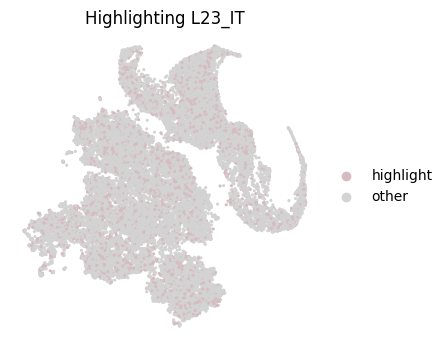

In [16]:
cell_type_to_highlight = "L23_IT"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata_covet.obs["highlight"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# # Plot UMAP with highlight vs other
# sc.pl.umap(
#     adata_covet,
#     color="highlight",
#     frameon=False,
#     title=f"Highlighting {cell_type_to_highlight}",
#     palette=[highlight_color, "lightgray"]
# )
#code to make the dots bigger in the umap plot
sc.pl.umap(
    adata_covet,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=[highlight_color, "lightgray"],
    size=20
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


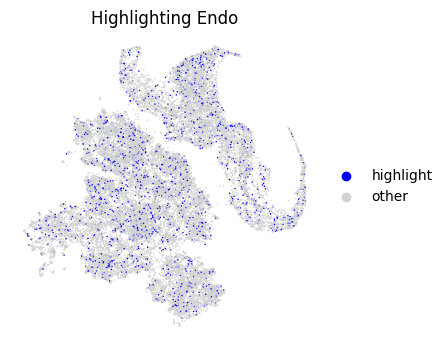

In [17]:
cell_type_to_highlight = "Endo"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata_covet.obs["highlight"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# # Plot UMAP with highlight vs other
# sc.pl.umap(
#     adata_covet,
#     color="highlight",
#     frameon=False,
#     title=f"Highlighting {cell_type_to_highlight}",
#     palette=[highlight_color, "lightgray"]
# )
#code to make the dots bigger in the umap plot
sc.pl.umap(
    adata_covet,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=["blue", "lightgray"],
    
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


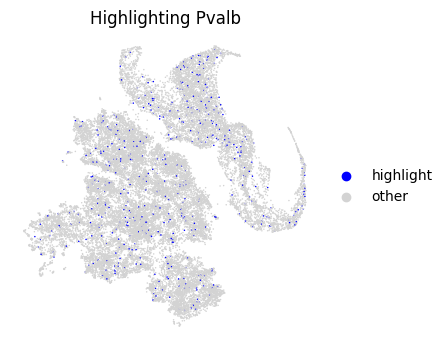

In [18]:
cell_type_to_highlight = "Pvalb"
highlight_color = cell_type_colors[cell_type_to_highlight]

# Make sure 'cell_type' is categorical
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata_covet.obs["highlight"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight" if x == cell_type_to_highlight else "other"
).astype("category")

# # Plot UMAP with highlight vs other
# sc.pl.umap(
#     adata_covet,
#     color="highlight",
#     frameon=False,
#     title=f"Highlighting {cell_type_to_highlight}",
#     palette=[highlight_color, "lightgray"]
# )
#code to make the dots bigger in the umap plot
sc.pl.umap(
    adata_covet,
    color="highlight",
    frameon=False,
    title=f"Highlighting {cell_type_to_highlight}",
    palette=["blue", "lightgray"],
    
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


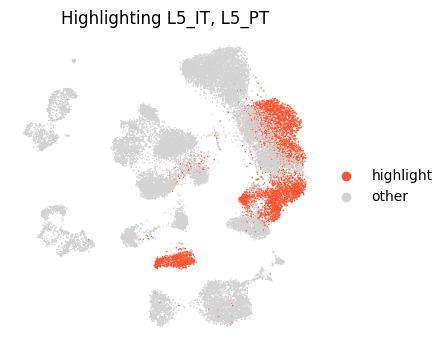

In [19]:
# Define the cell types to highlight
cell_types_to_highlight = ["L5_IT", "L5_PT"]
highlight_color = "#FF5733"  # Custom color for highlighting

# Make sure 'cell_type' is categorical
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata.obs["highlight"] = adata.obs["cell_type"].apply(
    lambda x: "highlight" if x in cell_types_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata,
    color="highlight",
    frameon=False,
    title=f"Highlighting {', '.join(cell_types_to_highlight)}",
    palette=[highlight_color, "lightgray"]
)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


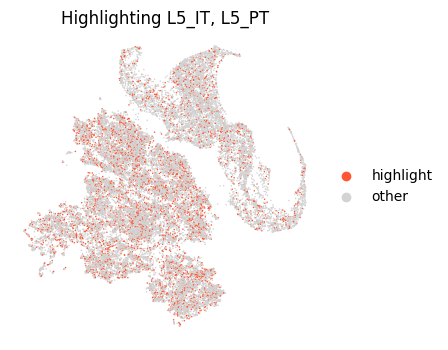

In [20]:
# Define the cell types to highlight
cell_types_to_highlight = ["L5_IT", "L5_PT"]
highlight_color = "#FF5733"  # Custom color for highlighting

# Make sure 'cell_type' is categorical
adata_covet.obs["cell_type"] = adata_covet.obs["cell_type"].astype("category")

# Create a categorical 'highlight' column with string labels
adata_covet.obs["highlight"] = adata_covet.obs["cell_type"].apply(
    lambda x: "highlight" if x in cell_types_to_highlight else "other"
).astype("category")

# Plot UMAP with highlight vs other
sc.pl.umap(
    adata_covet,
    color="highlight",
    frameon=False,
    title=f"Highlighting {', '.join(cell_types_to_highlight)}",
    palette=[highlight_color, "lightgray"]
)

# Clustering of a single cell type based on COVET embeddings

In [7]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [8]:
n_pcs_for_neighbors = min(50, adata.X.shape[1])

In [9]:
if adata.X.shape[0] <= 10 : # Ensure enough neighbors
    n_neighbors_val = max(1, adata.X.shape[0] -1)
else:
    n_neighbors_val = 10

In [10]:
print(f"Using {n_pcs_for_neighbors} PCs and {n_neighbors_val} neighbors for clustering.")


Using 50 PCs and 10 neighbors for clustering.


In [11]:
sc.pp.neighbors(adata, use_rep='X', n_neighbors=n_neighbors_val, n_pcs=n_pcs_for_neighbors)
sc.tl.leiden(adata, resolution=0.5, key_added='integrated_clusters')

In [ ]:
n_sc_cells = sc_ad.shape[0]
# It slices adata.obs['integrated_clusters'] starting from the index after the single-cell data ends (n_sc_cells)
# to the end, effectively getting the cluster labels for all spatial cells.
# .values converts the pandas Series to a NumPy array.
integrated_clusters_for_st_cells = adata.obs['integrated_clusters'].iloc[n_sc_cells:].values

In [19]:
integrated_clusters_for_st_cells

['3', '7', '11', '7', '5', ..., '3', '3', '2', '7', '11']
Length: 18516
Categories (18, object): ['0', '1', '2', '3', ..., '14', '15', '16', '17']

In [13]:
st_ad.obs['integrated_clusters'] = pd.Categorical(integrated_clusters_for_st_cells) # Ensure categorical for plotting
print("\nAvailable original cell types in st_ad:", st_ad.obs["cell_type"].unique())
target_original_cell_type = "L5_IT"  



Available original cell types in st_ad: ['Endo', 'Astro', 'Oligo', 'L5_IT', 'L6_IT', ..., 'L6_IT_Car3', 'Vip', 'Lamp5', 'Sncg', 'L6b']
Length: 22
Categories (22, object): ['Astro', 'Endo', 'L5_IT', 'L5_PT', ..., 'Sncg', 'Sst', 'VLMC', 'Vip']



Found 1471 cells of original type 'L5_IT' for spatial plotting.


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


<Figure size 800x800 with 0 Axes>

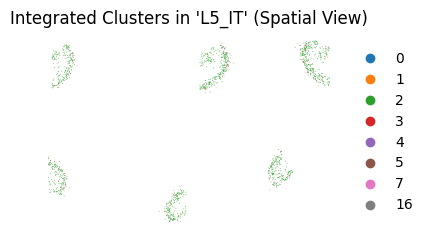

In [15]:
st_ad_subset_for_plotting = st_ad[st_ad.obs["cell_type"] == target_original_cell_type].copy()
if st_ad_subset_for_plotting.shape[0] == 0:
    print(f"\nNo cells found for original cell type '{target_original_cell_type}' in st_ad.")
    print("Please choose a valid cell type from the list above.")
else:
    print(f"\nFound {st_ad_subset_for_plotting.shape[0]} cells of original type '{target_original_cell_type}' for spatial plotting.")
    if 'spatial' not in st_ad_subset_for_plotting.obsm:
        print("Error: 'spatial' coordinates not found in st_ad_subset_for_plotting.obsm.")
    else:
        plt.figure(figsize=(8, 8))
        sc.pl.spatial(st_ad_subset_for_plotting,
                      color='integrated_clusters', # Color by the new clusters
                      groups=None, # Show all clusters, or specify: e.g., ['0', '1']
                      spot_size=30, # Adjust as needed
                      frameon=False,
                      show=False, # Use plt.show() for better control in scripts
                      title=f"Integrated Clusters in '{target_original_cell_type}' (Spatial View)")
        plt.show()


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


<Figure size 400x400 with 0 Axes>

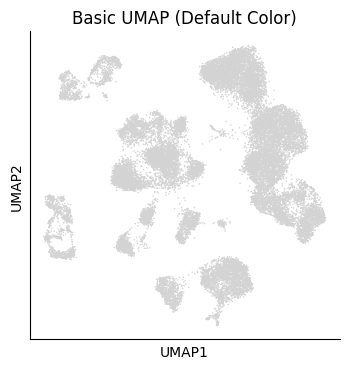

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Figure size 400x400 with 0 Axes>

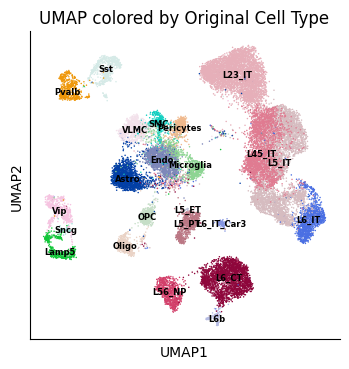

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Figure size 400x400 with 0 Axes>

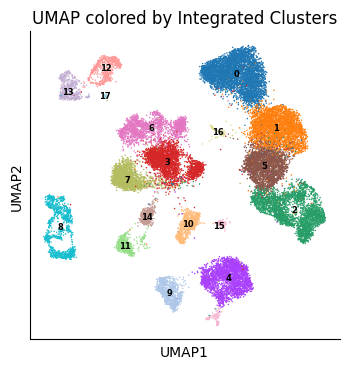

<Figure size 400x400 with 0 Axes>

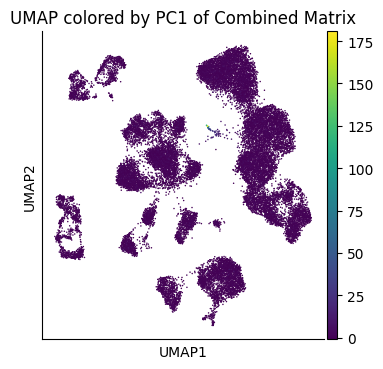

In [17]:
# Assuming 'adata' is your AnnData object from the previous script
# and 'integrated_clusters' and 'cell_type' are in adata.obs

# First, ensure UMAP coordinates are computed on this adata
if 'X_umap' not in adata.obsm_keys():
    print("UMAP coordinates not found, computing now...")
    # Ensure neighbors are computed using the correct representation (adata.X which is combined_matrix)
    n_pcs_for_neighbors = min(50, adata.X.shape[1])
    if adata.X.shape[0] <= 10:
        n_neighbors_val = max(1, adata.X.shape[0] - 1)
    else:
        n_neighbors_val = 10
    sc.pp.neighbors(adata, use_rep='X', n_neighbors=n_neighbors_val, n_pcs=n_pcs_for_neighbors)
    sc.tl.umap(adata, min_dist=0.3) # min_dist can be tuned

# Basic plot - check if anything appears
plt.figure()
sc.pl.umap(adata, show=False)
plt.title("Basic UMAP (Default Color)")
plt.show()

# Plot colored by original cell types
plt.figure()
sc.pl.umap(adata, color='cell_type', legend_loc='on data', legend_fontsize=6, show=False)
plt.title("UMAP colored by Original Cell Type")
plt.show()

# Plot colored by integrated clusters (if you computed them)
if 'integrated_clusters' in adata.obs.columns:
    plt.figure()
    sc.pl.umap(adata, color='integrated_clusters', legend_loc='on data', legend_fontsize=6, show=False)
    plt.title("UMAP colored by Integrated Clusters")
    plt.show()
else:
    print("'integrated_clusters' not found in adata.obs. Run sc.tl.leiden(adata, ...) first.")

# If your 'combined_matrix' (adata.X) has some continuous features you want to inspect
# (e.g., if the PCA components themselves are meaningful to plot)
if adata.X.shape[1] > 0:
    # Plotting first PCA component from the combined matrix (example)
    # You would need to add these PCs to .obs to color by them if they are not directly genes
    # For instance, if adata.X are the PCs themselves:
    adata.obs['PC1_combined'] = adata.X[:,0]
    plt.figure()
    sc.pl.umap(adata, color='PC1_combined', cmap='viridis', show=False)
    plt.title("UMAP colored by PC1 of Combined Matrix")
    plt.show()